# Example: two observers, one event

This notebook sits with the other short examples in `docs/notebooks/`.
The longer tutorials stay at the repository root
(`BAGLE_TUTORIAL.ipynb`, `model_fit_tutorial.ipynb`).

The inputs are illustrative. They are not a fit to a published event.
One lens and one source are seen from Earth and from Spitzer. OGLE
photometry and Keck astrometry are Earth. Spitzer photometry is the
spacecraft. HST astrometry is also Earth, with its own catalog origin
`xS0`. Each filter therefore has its own parallax vector, and each
astrometric filter has its own `xS0`.


## Build the event

`xS0_E` and `xS0_N` are arrays, one entry per filter, in the unified
order OGLE, Spitzer, Keck, HST, the same length as `b_sff` and
`mag_src`. `xS0[filt_idx]` is that filter's East/North origin.


In [1]:
import warnings
warnings.filterwarnings('ignore', category=SyntaxWarning)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from bagle import model
from bagle import model_fitter
from bagle.parallax import parallax_in_direction

plt.rcParams['figure.dpi'] = 72
plt.rcParams['savefig.dpi'] = 72
plt.rcParams['figure.figsize'] = (5.2, 3.2)

ra_deg = 270.0
dec_deg = -29.0
t0 = 57000.0
# East, North origin (arcsec): phot-only zeros, then Keck, then HST.
xS0_E = np.array([0.0, 0.0, 0.002, -0.003])
xS0_N = np.array([0.0, 0.0, -0.001, 0.004])
b_sff = np.array([0.90, 0.85, 1.0, 1.0])  # source flux fraction
mag_src = np.array([18.6, 17.9, 0.0, 0.0])
obs = ['earth', 'spitzer', 'earth', 'earth']

truth = model.PSPL_PhotAstrom_Par_Param1(
    5.0, t0, 0.3, 4000.0, 0.5,
    xS0_E, xS0_N,
    1.0, -1.0, 4.0, 0.5,
    b_sff, mag_src,
    raL=ra_deg, decL=dec_deg,
    obsLocation=obs,
)
print('xS0 shape', truth.xS0.shape)
print('observers', list(truth.obsLocation))


xS0 shape (4, 2)
observers ['earth', 'spitzer', 'earth', 'earth']


## Illustrative data

Photometry is drawn from filters 0 and 1. Astrometry is drawn from
filters 2 (Keck) and 3 (HST). Noise is small and fixed by a seed so
the notebook stays reproducible.


In [2]:
rng = np.random.default_rng(0)
t_ogle = np.linspace(t0 - 40.0, t0 + 40.0, 20)
t_spitzer = np.linspace(t0 - 30.0, t0 + 30.0, 12)
t_keck = np.linspace(t0 - 200.0, t0 + 200.0, 10)
t_hst = np.linspace(t0 - 150.0, t0 + 250.0, 8)

mag_ogle = truth.get_photometry(t_ogle, filt_idx=0)
mag_spitzer = truth.get_photometry(t_spitzer, filt_idx=1)
xy_keck = truth.get_astrometry(t_keck, filt_idx=2)
xy_hst = truth.get_astrometry(t_hst, filt_idx=3)

mag_ogle = mag_ogle + rng.normal(0.0, 0.02, mag_ogle.shape)
mag_spitzer = mag_spitzer + rng.normal(0.0, 0.02, mag_spitzer.shape)
xy_keck = xy_keck + rng.normal(0.0, 3.0e-4, xy_keck.shape)
xy_hst = xy_hst + rng.normal(0.0, 3.0e-4, xy_hst.shape)

data = {
    'raL': ra_deg,
    'decL': dec_deg,
    'target': 'illustrative',
    'phot_data': ['ogle', 'spitzer'],
    'ast_data': ['keck', 'hst'],
    'obsLocation': {
        'ogle': 'earth',
        'spitzer': 'spitzer',
        'keck': 'earth',
        'hst': 'earth',
    },
    't_phot1': t_ogle,
    'mag1': mag_ogle,
    'mag_err1': np.full(t_ogle.size, 0.02),
    't_phot2': t_spitzer,
    'mag2': mag_spitzer,
    'mag_err2': np.full(t_spitzer.size, 0.02),
    't_ast1': t_keck,
    'xpos1': xy_keck[:, 0],
    'ypos1': xy_keck[:, 1],
    'xpos_err1': np.full(t_keck.size, 3.0e-4),
    'ypos_err1': np.full(t_keck.size, 3.0e-4),
    't_ast2': t_hst,
    'xpos2': xy_hst[:, 0],
    'ypos2': xy_hst[:, 1],
    'xpos_err2': np.full(t_hst.size, 3.0e-4),
    'ypos_err2': np.full(t_hst.size, 3.0e-4),
}
print('filters will be phot names, then astrometry-only names')


filters will be phot names, then astrometry-only names


## Observer geometry

The parallax vector is the East/North offset of the observer from the
Solar System barycenter, in AU. Earth and Spitzer trace different
loops. Keck and HST share the Earth vector. Their astrometry still
differs because each catalog has its own `xS0`.


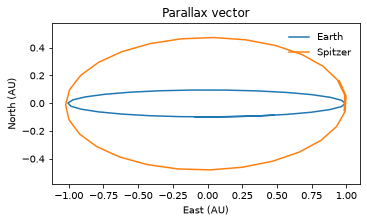

In [3]:
t_vec = np.linspace(56800.0, 57200.0, 30)
p_earth = parallax_in_direction(ra_deg, dec_deg, t_vec, obsLocation='earth')
p_spitz = parallax_in_direction(
    ra_deg, dec_deg, t_vec, obsLocation='spitzer'
)

fig, ax = plt.subplots()
ax.plot(p_earth[:, 0], p_earth[:, 1], label='Earth')
ax.plot(p_spitz[:, 0], p_spitz[:, 1], label='Spitzer')
ax.set_xlabel('East (AU)')
ax.set_ylabel('North (AU)')
ax.set_title('Parallax vector')
ax.set_aspect('equal', adjustable='datalim')
ax.legend(frameon=False)
fig.tight_layout()


## Light curves and astrometry

`filt_idx` selects the observer and the origin together. Spitzer's
light curve is not a copy of OGLE's. The two astrometric tracks are
separated by the difference in `xS0`.


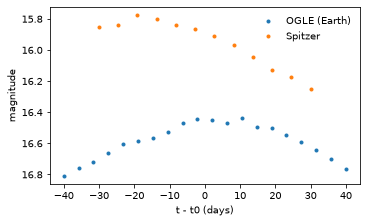

In [4]:
fig, ax = plt.subplots()
ax.plot(t_ogle - t0, mag_ogle, '.', label='OGLE (Earth)')
ax.plot(t_spitzer - t0, mag_spitzer, '.', label='Spitzer')
ax.invert_yaxis()
ax.set_xlabel('t - t0 (days)')
ax.set_ylabel('magnitude')
ax.legend(frameon=False)
fig.tight_layout()


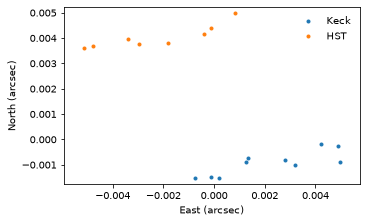

In [5]:
fig, ax = plt.subplots()
ax.plot(xy_keck[:, 0], xy_keck[:, 1], '.', label='Keck')
ax.plot(xy_hst[:, 0], xy_hst[:, 1], '.', label='HST')
ax.set_xlabel('East (arcsec)')
ax.set_ylabel('North (arcsec)')
ax.legend(frameon=False)
ax.set_aspect('equal', adjustable='datalim')
fig.tight_layout()


## Fitter

The cube expands filter parameters index-major and drops slots the
data do not use. OGLE and Spitzer have no astrometry, so `xS0_E1`
and `xS0_E2` are fixed at 0. Keck is unified filter 3 and HST is
filter 4, so the sampled origins are `xS0_E3` and `xS0_E4`. Priors
are one distribution per sampled suffix. The constructor argument
stays the array `xS0_E`.


In [6]:
def make_fitter():
    """Build a solver on the illustrative data. Do not sample."""
    return model_fitter.MicrolensSolver(
        data,
        model.PSPL_PhotAstrom_Par_Param1,
        outputfiles_basename='/tmp/bagle_multiloc_nb_',
        verbose=False,
    )

fitter = make_fitter()
print('filt_names', fitter.filt_names)
print('obs', list(fitter.obs_locations))
print('ast map', fitter.map_phot_idx_to_ast_idx)
print('cube', fitter.fitter_param_names)

# Narrow priors around the numbers used to draw the data.
fitter.priors['t0'] = model_fitter.make_gen(t0 - 5.0, t0 + 5.0)
fitter.priors['xS0_E3'] = model_fitter.make_gen(0.0, 0.004)
fitter.priors['xS0_N3'] = model_fitter.make_gen(-0.003, 0.001)
fitter.priors['xS0_E4'] = model_fitter.make_gen(-0.005, -0.001)
fitter.priors['xS0_N4'] = model_fitter.make_gen(0.002, 0.006)


filt_names ['ogle', 'spitzer', 'keck', 'hst']
obs ['earth', 'spitzer', 'earth', 'earth']
ast map [2, 3]
cube ['mL', 't0', 'beta', 'dL', 'dL_dS', 'xS0_E3', 'xS0_N3', 'xS0_E4', 'xS0_N4', 'muL_E', 'muL_N', 'muS_E', 'muS_N', 'b_sff1', 'mag_src1', 'b_sff2', 'mag_src2', 'b_sff3', 'b_sff4']


## Likelihood profile

This is a scan, not a nested-sampling fit. `t0` moves along the cube
and every other parameter stays at the value used to draw the data.
The peak should sit on that `t0`.


profile peak t0 = 57000.00 (drawn at 57000.00)


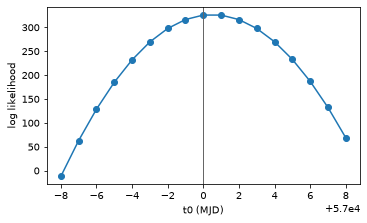

In [7]:
truth_values = {
    'mL': 5.0,
    't0': t0,
    'beta': 0.3,
    'dL': 4000.0,
    'dL_dS': 0.5,
    'muL_E': 1.0,
    'muL_N': -1.0,
    'muS_E': 4.0,
    'muS_N': 0.5,
    'xS0_E3': 0.002,
    'xS0_N3': -0.001,
    'xS0_E4': -0.003,
    'xS0_N4': 0.004,
    'b_sff1': 0.90,
    'b_sff2': 0.85,
    'b_sff3': 1.0,
    'b_sff4': 1.0,
    'mag_src1': 18.6,
    'mag_src2': 17.9,
}
names = list(fitter.fitter_param_names)
cube = np.array([truth_values[name] for name in names], dtype=float)
i_t0 = names.index('t0')

t_grid = np.linspace(t0 - 8.0, t0 + 8.0, 17)
lnL = np.empty(t_grid.size)
for i, t_try in enumerate(t_grid):
    trial = cube.copy()
    trial[i_t0] = t_try
    lnL[i] = float(fitter.log_likely(trial))

peak = float(t_grid[np.argmax(lnL)])
print(f'profile peak t0 = {peak:.2f} (drawn at {t0:.2f})')

fig, ax = plt.subplots()
ax.plot(t_grid, lnL, 'o-')
ax.axvline(t0, color='0.4', lw=1)
ax.set_xlabel('t0 (MJD)')
ax.set_ylabel('log likelihood')
fig.tight_layout()


## A tied origin, and the JAX likelihood

`tie_fit_param` drops HST's origin from the cube and copies Keck's
on every model build. The two tracks no longer match the data, so
the log-likelihood falls. The JAX likelihood reads that same source
column, so the two log-likelihoods agree at the untied point.


In [8]:
from bagle import model_fitter_jax

untied = float(fitter.log_likely(cube))
jax_fit = model_fitter_jax.MicrolensSolver(
    data,
    model_fitter_jax.mmodel.PSPL_PhotAstrom_Par_Param1,
    outputfiles_basename='/tmp/bagle_multiloc_nb_jax_',
    verbose=False,
)
ln_jax = float(jax_fit.evaluate_loglik_jax(cube))
print(f'untied numpy {untied:.6f}')
print(f'untied jax   {ln_jax:.6f}')
print(f'abs diff {abs(untied - ln_jax):.3e}')

tied = make_fitter()
tied.tie_fit_param('xS0_E4', 'xS0_E3')
tied.tie_fit_param('xS0_N4', 'xS0_N3')
tied_names = list(tied.fitter_param_names)
tied_cube = np.array(
    [truth_values[name] for name in tied_names], dtype=float
)
mod = tied.get_model(tied_cube)
print('Keck xS0', mod.xS0[2], 'HST xS0', mod.xS0[3])
print(f'tied lnL {float(tied.log_likely(tied_cube)):.3f}')


untied numpy 325.749091
untied jax   325.749091
abs diff 9.663e-13
Keck xS0 [ 0.002 -0.001] HST xS0 [ 0.002 -0.001]
tied lnL -1885.035
